## Cell 1: Import Library & Load Data Asli

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Mengatur tema visualisasi agar rapi dan profesional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Membaca data asli dari folder data (naik 1 tingkat dulu dari folder model)
df_asli = pd.read_csv('../data/milknew.csv')

print("Library berhasil dimuat.")
print(f"Dataset asli berhasil dibaca. Total data: {len(df_asli)} baris.")
display(df_asli.head())

Library berhasil dimuat.
Dataset asli berhasil dibaca. Total data: 1059 baris.


,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,6.6,35,1,0,1,0,254,high
1,6.6,36,0,1,0,1,253,high
2,8.5,70,1,1,1,1,246,low
3,9.5,34,1,1,0,1,255,low
4,6.6,37,0,0,0,0,255,medium


## Cell 2: EDA - Distribusi Fitur Numerik Kontinu (Suhu & pH)

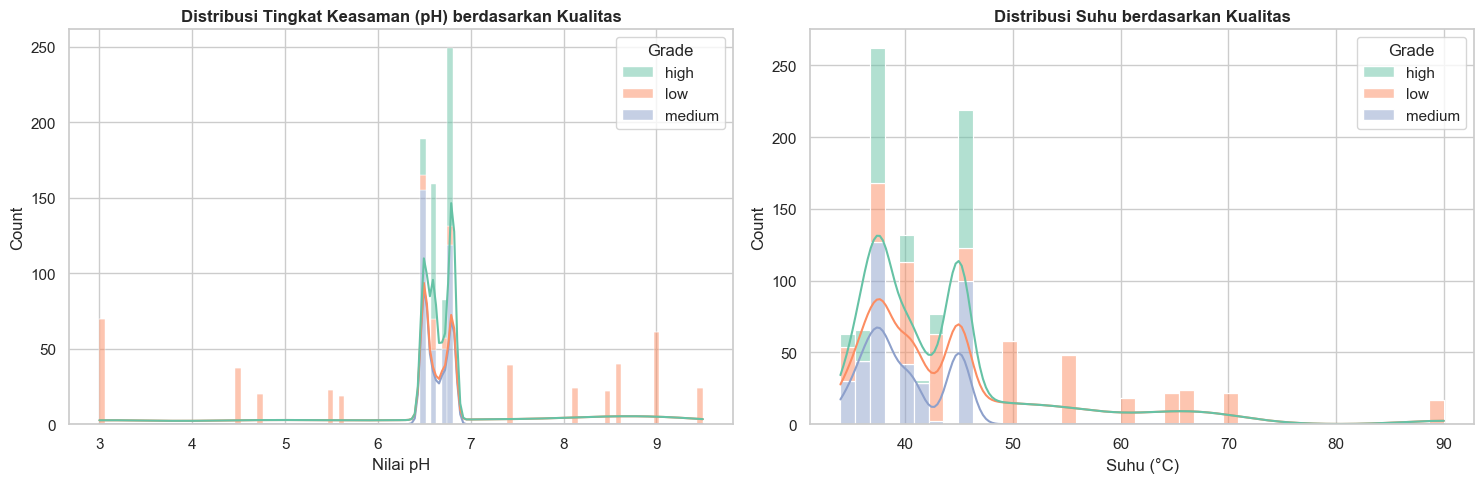

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histogram & KDE untuk pH
sns.histplot(data=df_asli, x='pH', hue='Grade', kde=True, ax=axes[0], palette='Set2', multiple='stack')
axes[0].set_title('Distribusi Tingkat Keasaman (pH) berdasarkan Kualitas', fontweight='bold')
axes[0].set_xlabel('Nilai pH')

# 2. Histogram & KDE untuk Suhu
sns.histplot(data=df_asli, x='Temprature', hue='Grade', kde=True, ax=axes[1], palette='Set2', multiple='stack')
axes[1].set_title('Distribusi Suhu berdasarkan Kualitas', fontweight='bold')
axes[1].set_xlabel('Suhu (°C)')

plt.tight_layout()
plt.show()

## Cell 3: EDA - Proporsi Fitur Kategorikal / Biner

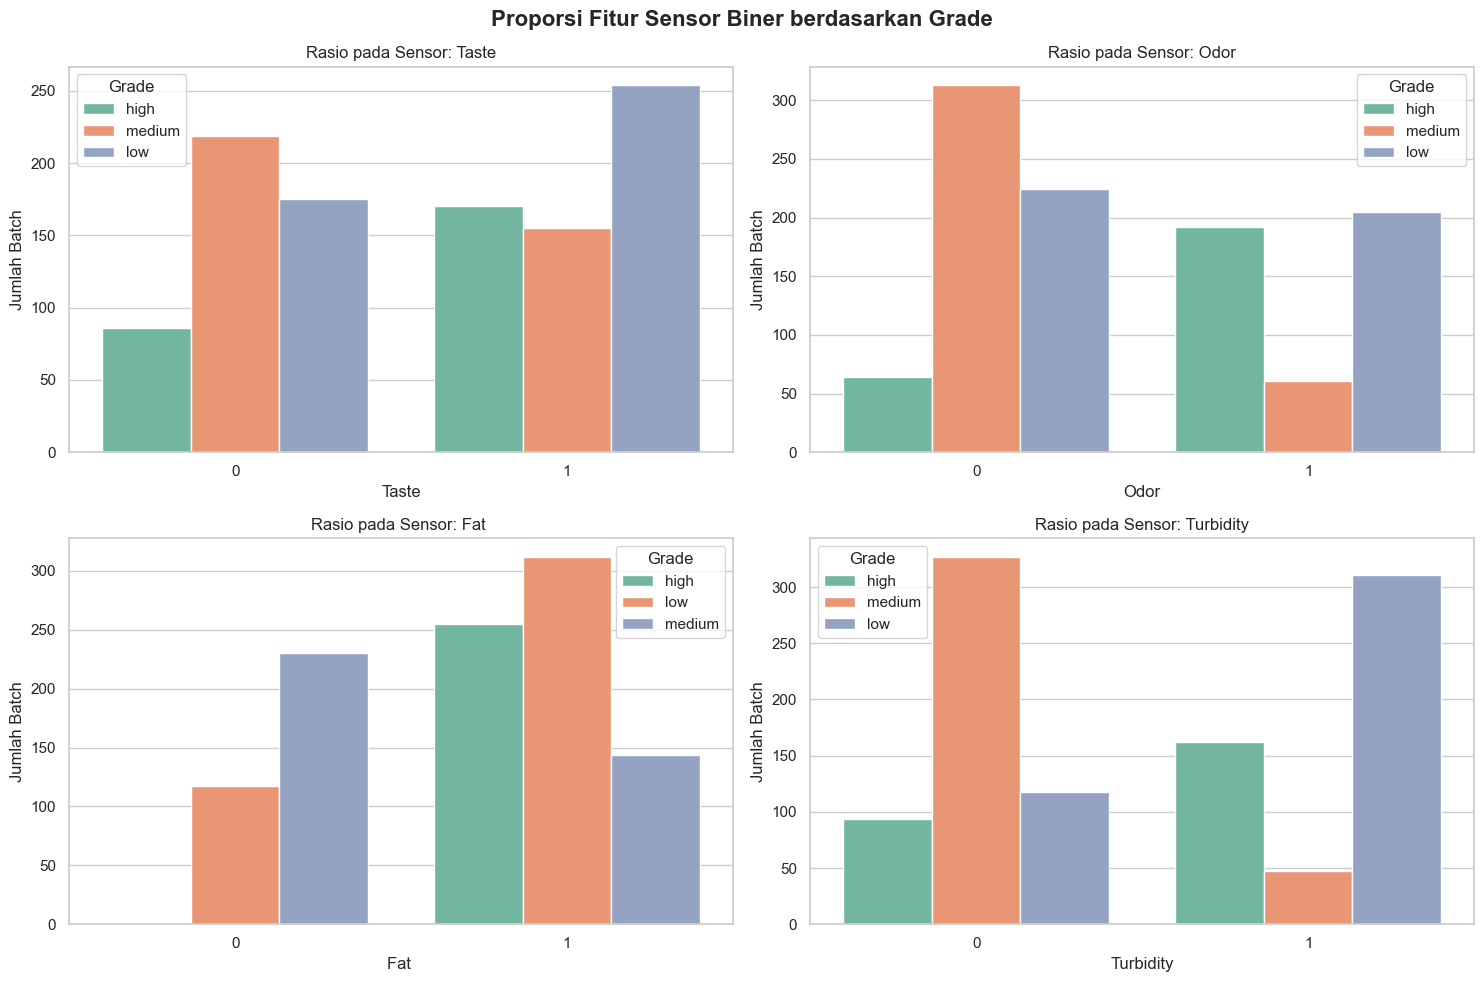

In [3]:
fitur_biner = ['Taste', 'Odor', 'Fat ', 'Turbidity']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Proporsi Fitur Sensor Biner berdasarkan Grade', fontsize=16, fontweight='bold')

for i, col in enumerate(fitur_biner):
    r = i // 2
    c = i % 2
    sns.countplot(data=df_asli, x=col, hue='Grade', ax=axes[r, c], palette='Set2')
    axes[r, c].set_title(f'Rasio pada Sensor: {col}')
    axes[r, c].set_ylabel('Jumlah Batch')

plt.tight_layout()
plt.show()

## Cell 4: Ekstraksi Parameter Statistik Data Normal

In [4]:
# Filter data normal (High dan Medium)
df_normal_asli = df_asli[df_asli['Grade'].str.lower().isin(['medium', 'high'])].copy()

# 1. Ekstraksi Mean dan Standar Deviasi untuk data numerik
ph_mean, ph_std = df_normal_asli['pH'].mean(), df_normal_asli['pH'].std()
temp_mean, temp_std = df_normal_asli['Temprature'].mean(), df_normal_asli['Temprature'].std()

# 2. Ekstraksi Distribusi Probabilitas untuk data biner/kategorikal
prob_taste = df_normal_asli['Taste'].value_counts(normalize=True)
prob_odor = df_normal_asli['Odor'].value_counts(normalize=True)
prob_fat = df_normal_asli['Fat '].value_counts(normalize=True)
prob_turb = df_normal_asli['Turbidity'].value_counts(normalize=True)
prob_col = df_normal_asli['Colour'].value_counts(normalize=True)

print("--- PARAMETER DISTRIBUSI DATA NORMAL ---")
print(f"pH         -> Rata-rata: {ph_mean:.2f}, Standar Deviasi: {ph_std:.2f}")
print(f"Suhu (°C)  -> Rata-rata: {temp_mean:.2f}, Standar Deviasi: {temp_std:.2f}")

--- PARAMETER DISTRIBUSI DATA NORMAL ---
pH         -> Rata-rata: 6.66, Standar Deviasi: 0.13
Suhu (°C)  -> Rata-rata: 40.10, Standar Deviasi: 3.69


## Cell 5: Pembuatan Struktur Waktu (Timestamp)

In [5]:
# 1. Parameter Simulasi
hari_simulasi = 30 # Kita perpanjang jadi 1 bulan agar data lebih masif
waktu_selesai = datetime.now()
waktu_mulai = waktu_selesai - timedelta(days=hari_simulasi)

# 2. Generate Semua Waktu (Interval 15 Menit)
# Membuat deret waktu dari 30 hari lalu hingga sekarang, lompat setiap 15 menit
semua_waktu = pd.date_range(start=waktu_mulai, end=waktu_selesai, freq='15min')

# 3. Filter Jam Operasional (Hanya 08:00 - 16:59)
# Membuang data malam hari untuk mensimulasikan pabrik yang tutup
daftar_waktu = [w for w in semua_waktu if 8 <= w.hour < 17]
jumlah_baris = len(daftar_waktu)

print(f"Berhasil menyusun {jumlah_baris} baris waktu simulasi.")
print(f"Interval Sensor : Setiap 15 Menit")
print(f"am Operasional : 08:00 - 17:00")
print(f"Awal Log  : {daftar_waktu[0].strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Akhir Log : {daftar_waktu[-1].strftime('%Y-%m-%d %H:%M:%S')}")

Berhasil menyusun 1080 baris waktu simulasi.
Interval Sensor : Setiap 15 Menit
am Operasional : 08:00 - 17:00
Awal Log  : 2026-05-02 08:14:23
Akhir Log : 2026-05-31 16:59:23


## Cell 6: Pembangkitan Data Sintetis Utama

In [6]:
# Mengunci angka acak agar hasil selalu konsisten saat dijalankan ulang
np.random.seed(42)

# ==========================================
# Kita pastikan 99% waktu operasional pabrik berjalan tanpa cacat
data_sintetis = {
    'Timestamp': daftar_waktu,
    'pH': np.random.normal(6.65, 0.03, jumlah_baris).round(2), 
    'Temprature': np.random.normal(37.0, 1.0, jumlah_baris).round(1),
    'Taste': np.ones(jumlah_baris, dtype=int),      # 1 = Normal
    'Odor': np.ones(jumlah_baris, dtype=int),       # 1 = Normal
    'Fat ': np.ones(jumlah_baris, dtype=int),       # 1 = Lemak Standar
    'Turbidity': np.zeros(jumlah_baris, dtype=int), # 0 = Normal
    'Colour': np.full(jumlah_baris, 255)            # 255 = Normal
}

df_sintetis = pd.DataFrame(data_sintetis)
print("Data simulasi normal berhasil dibangkitkan.")

Data simulasi normal berhasil dibangkitkan.


## Cell 7: Penyuntikan Kasus Kegagalan Operasional (Anomali Buatan)

In [7]:
# Skenario 1: Kegagalan Chiller (Hanya Suhu yang terdampak)
# Skenario 1: Kegagalan Chiller (Terjadi selama 2 jam = 8 baris)
df_sintetis.loc[150:157, 'Temprature'] = [43.5, 46.0, 49.5, 52.0, 54.5, 53.0, 50.1, 46.5]

# Skenario 2: Fermentasi Bakteri (pH turun, Rasa & Bau menyimpang)
df_sintetis.loc[400:405, 'pH'] = [6.4, 6.2, 6.1, 5.8, 6.1, 6.3]
df_sintetis.loc[400:405, 'Odor'] = [1, 0, 0, 0, 0, 1]
df_sintetis.loc[400:405, 'Taste'] = [1, 0, 0, 0, 0, 1]

# Skenario 3: Filter Strainer Jebol (Kekeruhan & Warna berubah)
df_sintetis.loc[700:703, 'Turbidity'] = [1, 1, 1, 1]
df_sintetis.loc[700:703, 'Colour'] = [252, 248, 245, 250]

# Skenario 4: Susu Dioplos Air oleh Peternak (Lemak drop, Rasa hambar)
df_sintetis.loc[900:902, 'Fat '] = [0, 0, 0]
df_sintetis.loc[900:902, 'Taste'] = [0, 0, 0]

# Skenario 5: Kontaminasi Darah/Mastitis (Warna drop drastis, pH agak basa)
# Terjadi di jam terakhir pabrik beroperasi (memicu alarm merah saat dashboard dibuka)
indeks_terakhir = jumlah_baris - 1
df_sintetis.loc[indeks_terakhir-2:indeks_terakhir, 'Colour'] = [240, 235, 230] 
df_sintetis.loc[indeks_terakhir-2:indeks_terakhir, 'pH'] = [6.8, 6.9, 7.1]

print("Skenario anomali pabrik berhasil disuntikkan ke dalam data runtun waktu.")

Skenario anomali pabrik berhasil disuntikkan ke dalam data runtun waktu.


## Cell 8 : Sanity Check

In [8]:
print("=== SANITY CHECK: KUALITAS DATA SINTETIS ===")

# 1. Cek Dimensi (Jumlah Baris & Kolom)
baris, kolom = df_sintetis.shape
print(f"Total Baris (Waktu) : {baris} (Target: 336)")
print(f"Total Kolom (Fitur) : {kolom} (Target: 8 kolom termasuk Timestamp)\n")

# 2. Cek Missing Values (Data Kosong) & Tipe Data
print("--- Info Tipe Data & Missing Values ---")
df_sintetis.info()

# 3. Cek Duplikasi Baris
jumlah_duplikat = df_sintetis.duplicated().sum()
print(f"\n--- Pengecekan Baris Duplikat ---")
print(f"Jumlah baris duplikat identik: {jumlah_duplikat}")

# 4. Preview Data Acak / Awal
print("\n--- Preview 5 Baris Pertama (Data Paling Lampau) ---")
display(df_sintetis.head())

=== SANITY CHECK: KUALITAS DATA SINTETIS ===
Total Baris (Waktu) : 1080 (Target: 336)
Total Kolom (Fitur) : 8 (Target: 8 kolom termasuk Timestamp)

--- Info Tipe Data & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Timestamp   1080 non-null   datetime64[ns]
 1   pH          1080 non-null   float64       
 2   Temprature  1080 non-null   float64       
 3   Taste       1080 non-null   int32         
 4   Odor        1080 non-null   int32         
 5   Fat         1080 non-null   int32         
 6   Turbidity   1080 non-null   int32         
 7   Colour      1080 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(5)
memory usage: 46.5 KB

--- Pengecekan Baris Duplikat ---
Jumlah baris duplikat identik: 0

--- Preview 5 Baris Pertama (Data Paling Lampau) ---


,Timestamp,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour
0,2026-05-02 08:14:23.873027,6.66,36.7,1,1,1,0,255
1,2026-05-02 08:29:23.873027,6.65,36.7,1,1,1,0,255
2,2026-05-02 08:44:23.873027,6.67,36.7,1,1,1,0,255
3,2026-05-02 08:59:23.873027,6.70,39.1,1,1,1,0,255
4,2026-05-02 09:14:23.873027,6.64,37.4,1,1,1,0,255


## Cell 9 : Export CSV

In [9]:
path_output = '../data/milk_syntethic_timeseries.csv'

# Export tanpa menuliskan nomor indeks baris bawaan pandas
df_sintetis.to_csv(path_output, index=False)

print(f"File sukses dibuat dan disimpan di: {path_output}")
print("\nCuplikan data runtun waktu terkini (5 baris terakhir):")
display(df_sintetis.tail())

File sukses dibuat dan disimpan di: ../data/milk_syntethic_timeseries.csv

Cuplikan data runtun waktu terkini (5 baris terakhir):


,Timestamp,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour
1075,2026-05-31 15:59:23.873027,6.64,36.4,1,1,1,0,255
1076,2026-05-31 16:14:23.873027,6.60,36.6,1,1,1,0,255
1077,2026-05-31 16:29:23.873027,6.80,36.7,1,1,1,0,240
1078,2026-05-31 16:44:23.873027,6.90,38.3,1,1,1,0,235
1079,2026-05-31 16:59:23.873027,7.10,37.6,1,1,1,0,230
